## Install & imports

In [ ]:
!pip install -q librosa scikit-learn seaborn joblib

import os, glob, json, numpy as np, pandas as pd
import librosa, librosa.display
import matplotlib.pyplot as plt, seaborn as sns
import joblib
from tqdm.auto import tqdm

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                             confusion_matrix, classification_report)

SEED = 42
np.random.seed(SEED)
SR = 22050
N_MFCC = 40
print("Ready.")

Ready.


## Download RAVDESS speech audio

In [ ]:
!wget -q https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip -O ravdess_speech.zip
!unzip -q ravdess_speech.zip -d ravdess
!find ravdess -name "*.wav" | head -3

ravdess/Actor_11/03-01-02-01-01-01-11.wav
ravdess/Actor_11/03-01-05-02-01-02-11.wav
ravdess/Actor_11/03-01-08-01-01-01-11.wav


## Build the dataframe (filter to 4 emotions)

In [ ]:
EMOTION_MAP = {'01': 'neutral', '03': 'happy', '04': 'sad', '05': 'angry'}

files = glob.glob('ravdess/**/*.wav', recursive=True)
rows = []
for f in files:
    parts = os.path.basename(f).replace('.wav','').split('-')
    if len(parts) != 7:
        continue
    emo = EMOTION_MAP.get(parts[2])
    actor = int(parts[6])
    if emo:
        rows.append({'path': f, 'emotion': emo, 'actor': actor})

df = pd.DataFrame(rows).reset_index(drop=True)
print("Total clips:", len(df))
print(df['emotion'].value_counts())
print("Actors:", sorted(df['actor'].unique()))

Total clips: 672
emotion
angry      192
happy      192
sad        192
neutral     96
Name: count, dtype: int64
Actors: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]


## Class counts plot

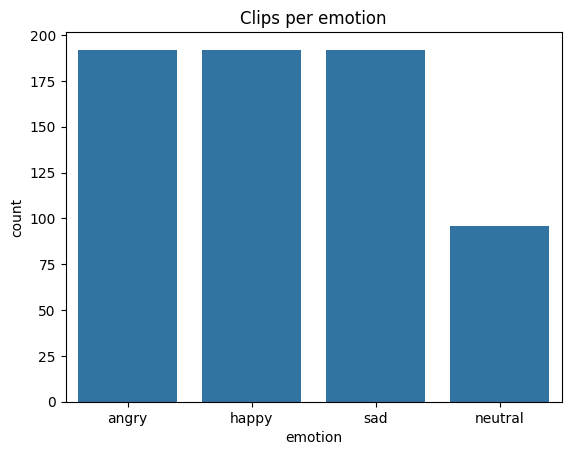

In [ ]:
order = ['angry','happy','sad','neutral']
sns.countplot(data=df, x='emotion', order=order)
plt.title('Clips per emotion'); plt.show()

## Waveform + mel spectrogram per emotion

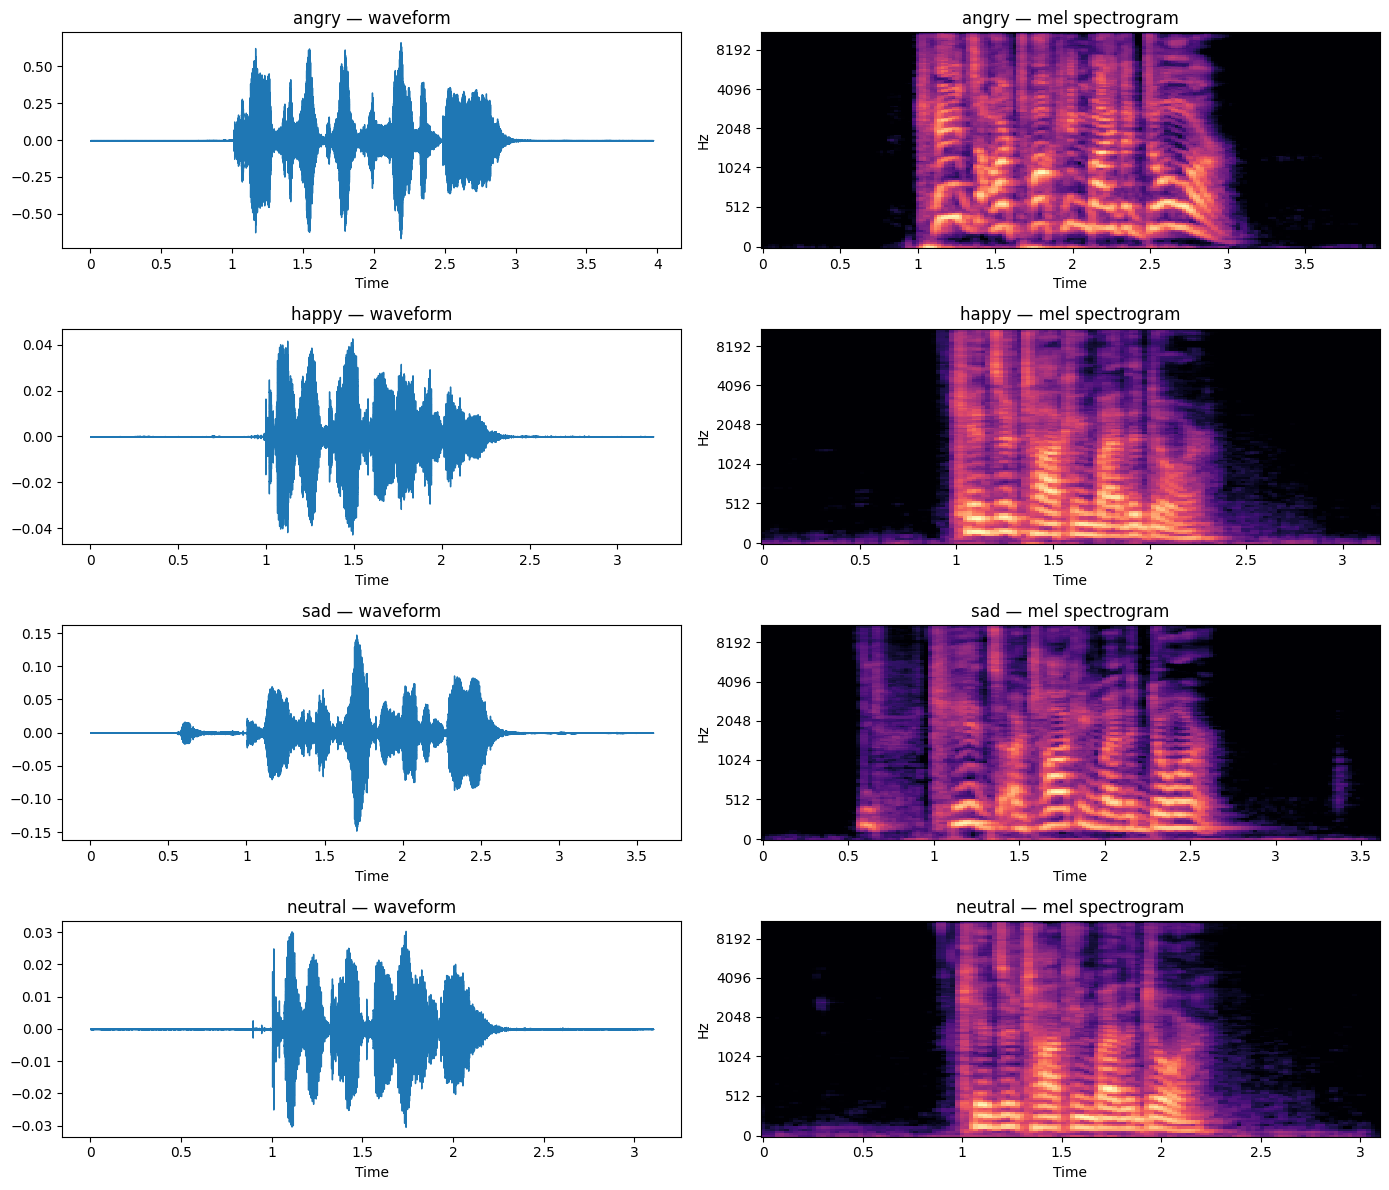

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
for i, emo in enumerate(order):
    path = df[df['emotion']==emo].iloc[0]['path']
    y, sr = librosa.load(path, sr=SR)

    librosa.display.waveshow(y, sr=sr, ax=axes[i,0])
    axes[i,0].set_title(f'{emo} — waveform')

    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    S_db = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time',
                             y_axis='mel', ax=axes[i,1])
    axes[i,1].set_title(f'{emo} — mel spectrogram')

plt.tight_layout(); plt.show()

## MFCC feature extraction

In [ ]:
def extract_mfcc(path, sr=SR, n_mfcc=N_MFCC):
    y, _ = librosa.load(path, sr=sr)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.mean(axis=1)   # shape (40,)

X = np.zeros((len(df), N_MFCC), dtype=np.float32)
for i, p in enumerate(tqdm(df['path'].values, desc='MFCC')):
    X[i] = extract_mfcc(p)

feat_cols = [f'mfcc_{j}' for j in range(N_MFCC)]
df_feat = pd.concat([df, pd.DataFrame(X, columns=feat_cols)], axis=1)
df_feat.to_csv('ravdess_mfcc_features.csv', index=False)
print(df_feat.shape)

MFCC:   0%|          | 0/672 [00:00<?, ?it/s]

(672, 43)


## Actor-based split (1–18 train, 19–24 test)

In [ ]:
train_df = df_feat[df_feat['actor'] <= 18].reset_index(drop=True)
test_df  = df_feat[df_feat['actor'] >= 19].reset_index(drop=True)

X_train, y_train = train_df[feat_cols].values, train_df['emotion'].values
X_test,  y_test  = test_df[feat_cols].values,  test_df['emotion'].values

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train dist:\n", train_df['emotion'].value_counts())
print("Test  dist:\n", test_df['emotion'].value_counts())

Train: (504, 40)  Test: (168, 40)
Train dist:
 emotion
angry      144
happy      144
sad        144
neutral     72
Name: count, dtype: int64
Test  dist:
 emotion
angry      48
sad        48
happy      48
neutral    24
Name: count, dtype: int64


## Train Random Forest

In [ ]:
rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=SEED, n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
print(f"RF  Accuracy: {acc_rf:.4f}   Macro-F1: {f1_rf:.4f}")
print(classification_report(y_test, y_pred_rf))

RF  Accuracy: 0.5060   Macro-F1: 0.4500
              precision    recall  f1-score   support

       angry       0.59      0.79      0.68        48
       happy       0.44      0.33      0.38        48
     neutral       0.31      0.17      0.22        24
         sad       0.49      0.56      0.52        48

    accuracy                           0.51       168
   macro avg       0.46      0.46      0.45       168
weighted avg       0.48      0.51      0.48       168



## Train SVM (with scaler)

In [ ]:
svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=10, gamma='scale',
                class_weight='balanced',
                probability=True, random_state=SEED))
])
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm  = f1_score(y_test, y_pred_svm, average='macro')
print(f"SVM Accuracy: {acc_svm:.4f}   Macro-F1: {f1_svm:.4f}")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.5893   Macro-F1: 0.5725
              precision    recall  f1-score   support

       angry       0.67      0.81      0.74        48
       happy       0.50      0.52      0.51        48
     neutral       0.48      0.50      0.49        24
         sad       0.66      0.48      0.55        48

    accuracy                           0.59       168
   macro avg       0.58      0.58      0.57       168
weighted avg       0.59      0.59      0.58       168



## Confusion matrices side by side

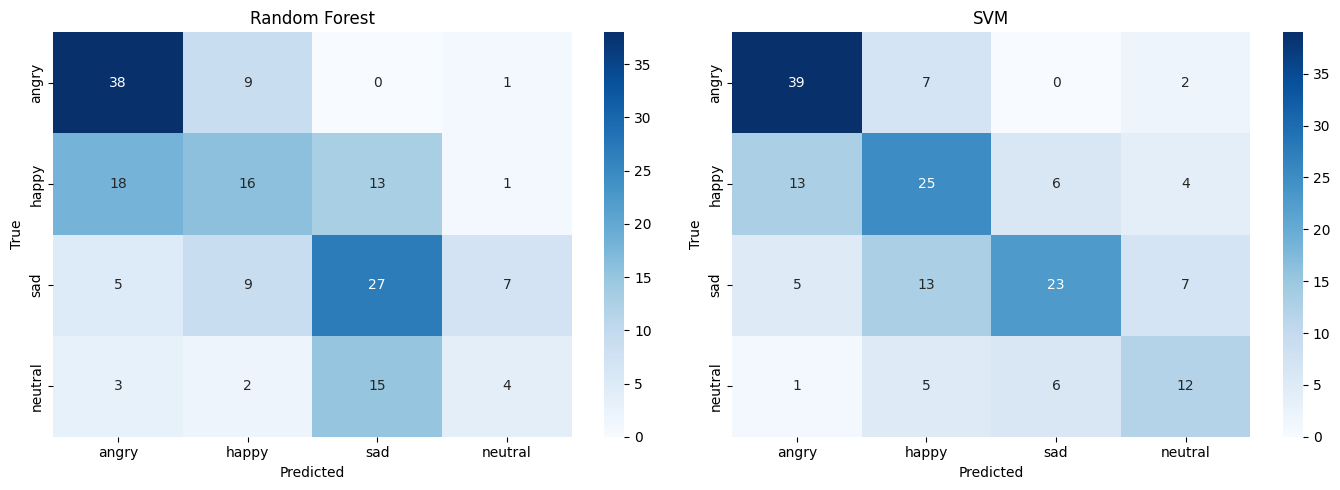

In [ ]:
labels = ['angry','happy','sad','neutral']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes,
        [('Random Forest', y_pred_rf), ('SVM', y_pred_svm)]):
    cm = confusion_matrix(y_test, pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{name}'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.show()

## Save the best model + metrics

In [ ]:
best_name  = 'svm' if f1_svm >= f1_rf else 'rf'
best_model = svm if best_name == 'svm' else rf
y_pred_best = y_pred_svm if best_name == 'svm' else y_pred_rf

os.makedirs('artifacts', exist_ok=True)
joblib.dump(best_model, f'artifacts/{best_name}_model.joblib')

metrics = {
    "best_model": best_name,
    "accuracy": float(accuracy_score(y_test, y_pred_best)),
    "macro_f1": float(f1_score(y_test, y_pred_best, average='macro')),
    "labels": labels,
    "confusion_matrix": confusion_matrix(y_test, y_pred_best, labels=labels).tolist(),
    "class_counts": df['emotion'].value_counts().to_dict(),
    "actor_split": {"train": list(range(1,19)), "test": list(range(19,25))},
    "sr": SR, "n_mfcc": N_MFCC
}
with open('artifacts/metrics.json','w') as f:
    json.dump(metrics, f, indent=2)

print("Best model:", best_name)
print(os.listdir('artifacts'))

Best model: svm
['svm_model.joblib', 'metrics.json']


## Download artifacts

In [ ]:
from google.colab import files
files.download(f'artifacts/{best_name}_model.joblib')
files.download('artifacts/metrics.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Download Sample clips

In [ ]:
import glob, os, shutil
os.makedirs('sample_clips', exist_ok=True)
for actor in [19, 20, 21, 22, 23, 24]:
    for emo_code in ['01','03','04','05']:   # neutral, happy, sad, angry
        matches = glob.glob(f'ravdess/**/Actor_{actor:02d}/03-01-{emo_code}-*.wav',
                            recursive=True)
        if matches:
            shutil.copy(matches[0], f'sample_clips/actor{actor}_{emo_code}.wav')
print(sorted(os.listdir('sample_clips')))


['actor19_01.wav', 'actor19_03.wav', 'actor19_04.wav', 'actor19_05.wav', 'actor20_01.wav', 'actor20_03.wav', 'actor20_04.wav', 'actor20_05.wav', 'actor21_01.wav', 'actor21_03.wav', 'actor21_04.wav', 'actor21_05.wav', 'actor22_01.wav', 'actor22_03.wav', 'actor22_04.wav', 'actor22_05.wav', 'actor23_01.wav', 'actor23_03.wav', 'actor23_04.wav', 'actor23_05.wav', 'actor24_01.wav', 'actor24_03.wav', 'actor24_04.wav', 'actor24_05.wav']


In [ ]:
shutil.make_archive('sample_clips', 'zip', 'sample_clips')
from google.colab import files
files.download('sample_clips.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>